# Practica ML paso a paso


#Creacion del dataset

Crear el dataset de clientes

In [3]:
# ================================
# PASO 1 - CREAR DATASET DE CLIENTES
# ================================

import pandas as pd
import numpy as np

# Para obtener siempre los mismos resultados
np.random.seed(42)

# Cantidad de clientes
n_clientes = 1000

# Crear dataset
df = pd.DataFrame({
    'customer_id': range(1, n_clientes + 1),

    'age': np.random.randint(
        18, 71, n_clientes
    ),

    'monthly_spend': np.random.gamma(
        shape=2,
        scale=100,
        size=n_clientes
    ).round(2),

    'total_purchases': np.random.poisson(
        lam=5,
        size=n_clientes
    ),

    'days_since_last_purchase': np.random.randint(
        1, 181, n_clientes
    ),

    'membership_type': np.random.choice(
        ['Basic', 'Premium', 'VIP'],
        size=n_clientes,
        p=[0.5, 0.35, 0.15]
    ),

    'gender': np.random.choice(
        ['Male', 'Female'],
        size=n_clientes
    ),

    'city': np.random.choice(
        ['Buenos Aires', 'Cordoba', 'Rosario', 'Mendoza', 'Tucuman'],
        size=n_clientes
    )
})

# Crear variable objetivo
# 1 = comprará el próximo mes
# 0 = no comprará

probabilidad_compra = (
    0.2
    + 0.002 * df['monthly_spend']
    + 0.05 * df['total_purchases']
    - 0.002 * df['days_since_last_purchase']
)

# Limitar probabilidades entre 0 y 1
probabilidad_compra = np.clip(
    probabilidad_compra,
    0.05,
    0.95
)

df['will_purchase_next_month'] = np.random.binomial(
    1,
    probabilidad_compra
)

# Mostrar primeras filas
display(df.head())

,customer_id,age,monthly_spend,total_purchases,days_since_last_purchase,membership_type,gender,city,will_purchase_next_month
0,1,56,292.69,7,162,Basic,Male,Mendoza,1
1,2,69,175.73,6,95,Basic,Female,Tucuman,1
2,3,46,518.46,3,56,Premium,Female,Rosario,1
3,4,32,201.43,5,32,Basic,Male,Cordoba,0
4,5,60,223.86,6,116,Premium,Male,Rosario,0


Revisar el dataset

In [4]:
# ================================
# PASO 2 - REVISAR DATASET
# ================================

print("Dimensiones del dataset:")
print(df.shape)

print("\nInformación general:")
df.info()

print("\nPrimeras filas:")
display(df.head())

print("\nValores faltantes:")
print(df.isna().sum())

print("\nDistribución de la variable objetivo:")
print(df['will_purchase_next_month'].value_counts())

Dimensiones del dataset:
(1000, 9)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1000 non-null   int64  
 1   age                       1000 non-null   int64  
 2   monthly_spend             1000 non-null   float64
 3   total_purchases           1000 non-null   int64  
 4   days_since_last_purchase  1000 non-null   int64  
 5   membership_type           1000 non-null   object 
 6   gender                    1000 non-null   object 
 7   city                      1000 non-null   object 
 8   will_purchase_next_month  1000 non-null   int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 70.4+ KB

Primeras filas:


,customer_id,age,monthly_spend,total_purchases,days_since_last_purchase,membership_type,gender,city,will_purchase_next_month
0,1,56,292.69,7,162,Basic,Male,Mendoza,1
1,2,69,175.73,6,95,Basic,Female,Tucuman,1
2,3,46,518.46,3,56,Premium,Female,Rosario,1
3,4,32,201.43,5,32,Basic,Male,Cordoba,0
4,5,60,223.86,6,116,Premium,Male,Rosario,0



Valores faltantes:
customer_id                 0
age                         0
monthly_spend               0
total_purchases             0
days_since_last_purchase    0
membership_type             0
gender                      0
city                        0
will_purchase_next_month    0
dtype: int64

Distribución de la variable objetivo:
will_purchase_next_month
1    609
0    391
Name: count, dtype: int64


Agregar valores faltantes

In [5]:
# ================================
# PASO 3 - CREAR VALORES FALTANTES
# ================================

# Crear una copia
df_practica = df.copy()

# Crear valores faltantes en variables numéricas
df_practica.loc[
    np.random.choice(df_practica.index, 30, replace=False),
    'monthly_spend'
] = np.nan

df_practica.loc[
    np.random.choice(df_practica.index, 20, replace=False),
    'age'
] = np.nan

# Crear valores faltantes en variables categóricas
df_practica.loc[
    np.random.choice(df_practica.index, 25, replace=False),
    'membership_type'
] = np.nan

# Mostrar cantidad de valores faltantes
print("Valores faltantes por columna:")

print(
    df_practica.isna().sum()
)

Valores faltantes por columna:
customer_id                  0
age                         20
monthly_spend               30
total_purchases              0
days_since_last_purchase     0
membership_type             25
gender                       0
city                         0
will_purchase_next_month     0
dtype: int64


Guardar el dataset

In [6]:
# ================================
# PASO 4 - GUARDAR DATASET
# ================================

ruta = '/content/ml_intro_simulated.csv'

df_practica.to_csv(
    ruta,
    index=False
)

print("Dataset guardado correctamente en:")
print(ruta)

Dataset guardado correctamente en:
/content/ml_intro_simulated.csv


In [8]:
# ================================
# PRÁCTICA ML – CÓDIGO INICIAL
# ================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

RANDOM_STATE = 42

# ----------------
# 1. CARGA DATOS
# ----------------
# Usar el dataset generado previamente o subir uno propio
# Ejemplo:
# df = pd.read_csv('/content/ml_intro_simulated.csv')

# Fix: The file '/content/ml_intro_simulated.csv' was not found.
# Please ensure the file is uploaded or specify the correct path to your dataset.
# df = pd.read_csv('/content/ml_intro_simulated.csv') # Original line causing error
#raise FileNotFoundError("Please upload 'ml_intro_simulated.csv' or update the path to your dataset.")
df = pd.read_csv('/content/ml_intro_simulated.csv')
print("Primeras filas:")
display(df.head())

print("\nInformación general:")
df.info()

print("\nValores faltantes por columna:")
print(df.isna().sum())

# ----------------
# 2. VARIABLE OBJETIVO
# ----------------
TARGET = 'will_purchase_next_month'

X = df.drop(columns=[TARGET])
y = df[TARGET]

# ----------------
# 3. FEATURE ENGINEERING (placeholder)
# ----------------
# TODO:
# - Crear al menos dos variables derivadas relevantes
# - Justificar su creación en el informe
# Ejemplo (NO implementar todavía):
# X['feature_x'] = ...

# ----------------
# 4. VISUALIZACIÓN EXPLORATORIA
# ----------------
# TODO:
# - Graficar distribuciones
# - Detectar outliers o patrones
# Ejemplo:
# sns.histplot(...)
# plt.show()

# ----------------
# 5. DEFINIR COLUMNAS
# ----------------
num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include=['object','category']).columns

print("Variables numéricas:", list(num_features))
print("Variables categóricas:", list(cat_features))

# ----------------
# 6. PREPROCESAMIENTO (PIPELINE)
# ----------------
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_features),
        ('cat', categorical_pipeline, cat_features)
    ]
)

# ----------------
# 7. SPLIT DE DATOS
# ----------------
# División train / validation / test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 x 0.8 = 0.2
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Shapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# ----------------
# 8. APLICAR PREPROCESAMIENTO
# ----------------
# Importante: fit SOLO con training (prevención de data leakage)

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print("Datos preprocesados correctamente.")

Primeras filas:


,customer_id,age,monthly_spend,total_purchases,days_since_last_purchase,membership_type,gender,city,will_purchase_next_month
0,1,56.0,292.69,7,162,Basic,Male,Mendoza,1
1,2,69.0,175.73,6,95,Basic,Female,Tucuman,1
2,3,46.0,518.46,3,56,Premium,Female,Rosario,1
3,4,32.0,201.43,5,32,Basic,Male,Cordoba,0
4,5,60.0,223.86,6,116,Premium,Male,Rosario,0



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1000 non-null   int64  
 1   age                       980 non-null    float64
 2   monthly_spend             970 non-null    float64
 3   total_purchases           1000 non-null   int64  
 4   days_since_last_purchase  1000 non-null   int64  
 5   membership_type           975 non-null    object 
 6   gender                    1000 non-null   object 
 7   city                      1000 non-null   object 
 8   will_purchase_next_month  1000 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 70.4+ KB

Valores faltantes por columna:
customer_id                  0
age                         20
monthly_spend               30
total_purchases              0
days_since_last_purchase     0
membership_type   

Definir la variable objetivo

In [9]:
# ================================
# 2. VARIABLE OBJETIVO
# ================================

TARGET = 'will_purchase_next_month'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(TARGET)

print("\nDistribución de la variable objetivo:")
print(y.value_counts())

print("\nProporción de clases:")
print(y.value_counts(normalize=True))

Variables predictoras:
['customer_id', 'age', 'monthly_spend', 'total_purchases', 'days_since_last_purchase', 'membership_type', 'gender', 'city']

Variable objetivo:
will_purchase_next_month

Distribución de la variable objetivo:
will_purchase_next_month
1    609
0    391
Name: count, dtype: int64

Proporción de clases:
will_purchase_next_month
1    0.609
0    0.391
Name: proportion, dtype: float64


Feature Engineering

In [10]:
# ================================
# 3. FEATURE ENGINEERING
# ================================

# Ver nombres de columnas disponibles
print("Columnas disponibles:")
print(X.columns.tolist())

# Crear variables derivadas
X['avg_spend_per_purchase'] = (
    X['monthly_spend'] / (X['total_purchases'] + 1)
)

X['purchase_frequency'] = (
    X['total_purchases'] / (X['days_since_last_purchase'] + 1)
)

print("\nNuevas variables creadas:")
print("- avg_spend_per_purchase")
print("- purchase_frequency")

display(X.head())

Columnas disponibles:
['customer_id', 'age', 'monthly_spend', 'total_purchases', 'days_since_last_purchase', 'membership_type', 'gender', 'city']

Nuevas variables creadas:
- avg_spend_per_purchase
- purchase_frequency


,customer_id,age,monthly_spend,total_purchases,days_since_last_purchase,membership_type,gender,city,avg_spend_per_purchase,purchase_frequency
0,1,56.0,292.69,7,162,Basic,Male,Mendoza,36.586250,0.042945
1,2,69.0,175.73,6,95,Basic,Female,Tucuman,25.104286,0.062500
2,3,46.0,518.46,3,56,Premium,Female,Rosario,129.615000,0.052632
3,4,32.0,201.43,5,32,Basic,Male,Cordoba,33.571667,0.151515
4,5,60.0,223.86,6,116,Premium,Male,Rosario,31.980000,0.051282



Se crearon dos variables derivadas.

La primera

```
avg_spend_per_purchase
```


 representa el gasto promedio realizado por cada compra y permite analizar el valor económico de los clientes.


La segunda

```
purchase_frequency
```

relaciona la cantidad de compras con los días transcurridos desde la última compra, proporcionando una aproximación al nivel de actividad del cliente.




In [11]:
print(X.columns.tolist())

['customer_id', 'age', 'monthly_spend', 'total_purchases', 'days_since_last_purchase', 'membership_type', 'gender', 'city', 'avg_spend_per_purchase', 'purchase_frequency']


Visualización exploratoria

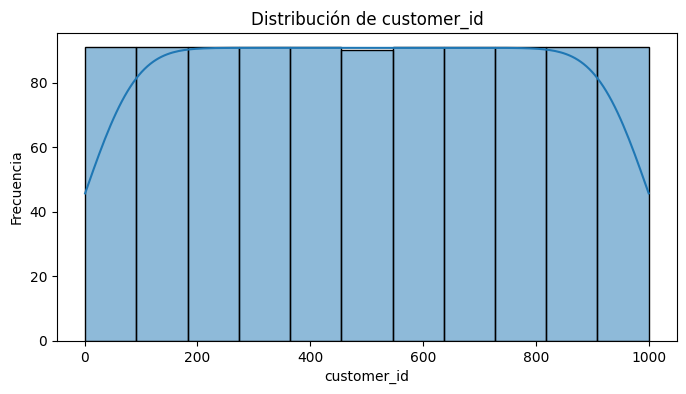

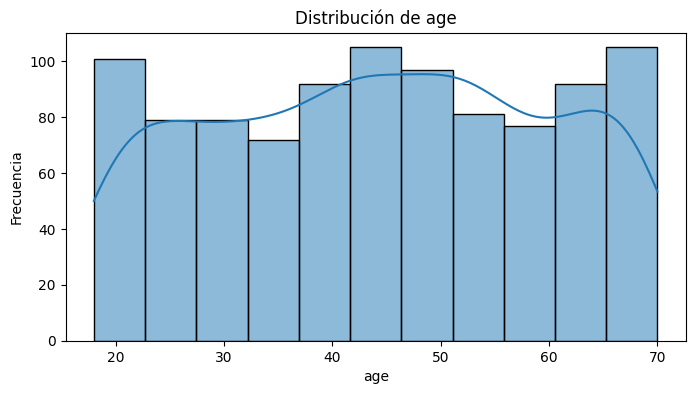

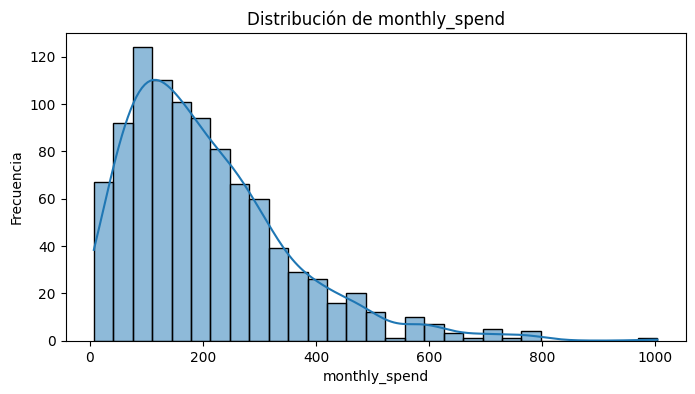

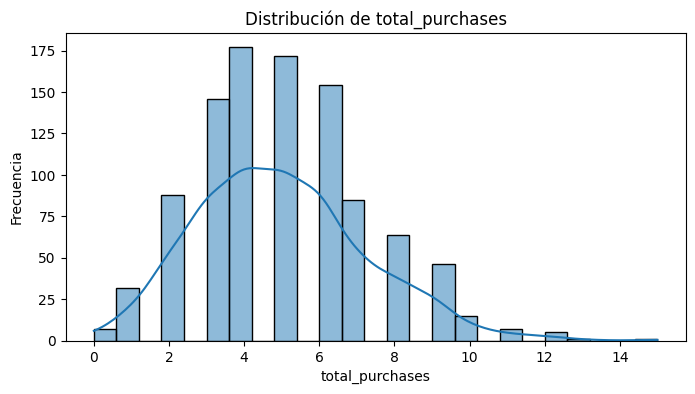

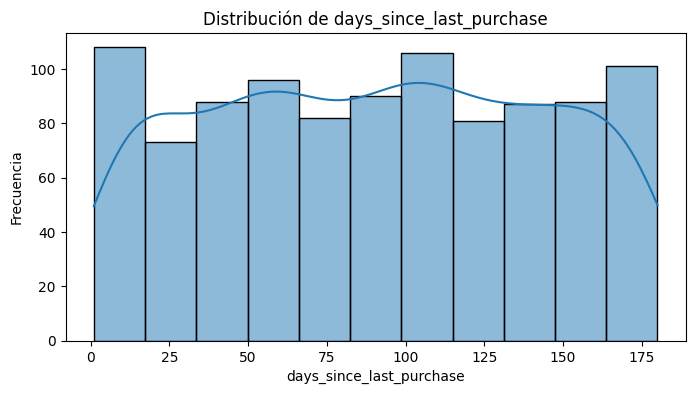

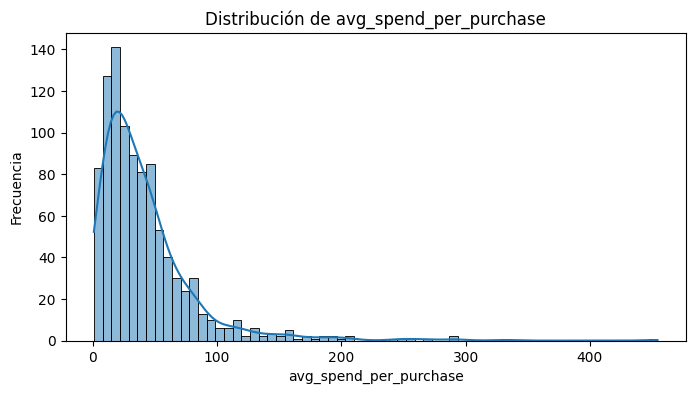

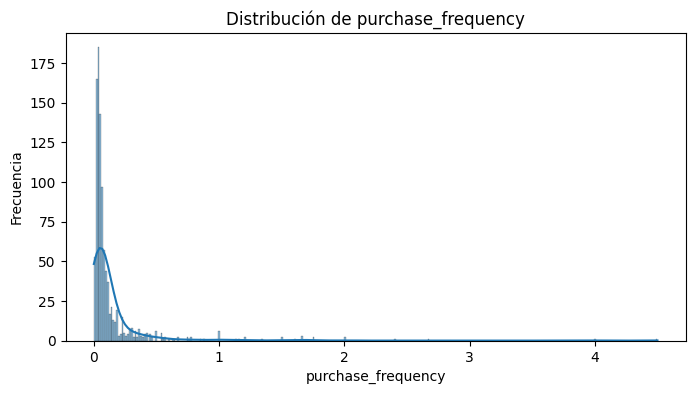

In [12]:
# ================================
# 4. VISUALIZACIÓN EXPLORATORIA
# ================================

# Histograma de variables numéricas
numeric_columns = X.select_dtypes(
    include=['int64', 'float64']
).columns

for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=X,
        x=column,
        kde=True
    )

    plt.title(f'Distribución de {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.show()

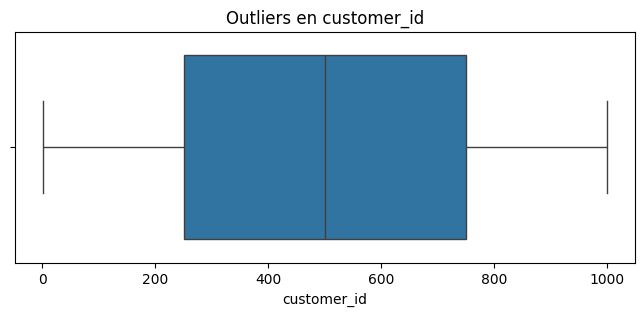

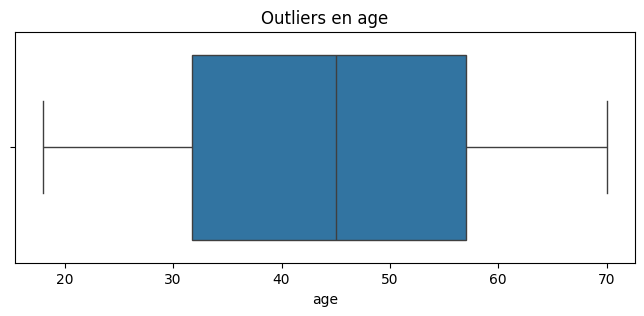

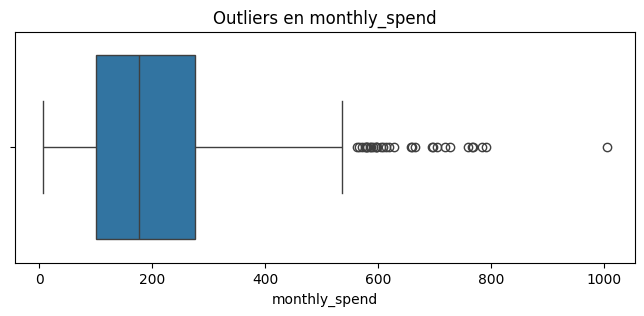

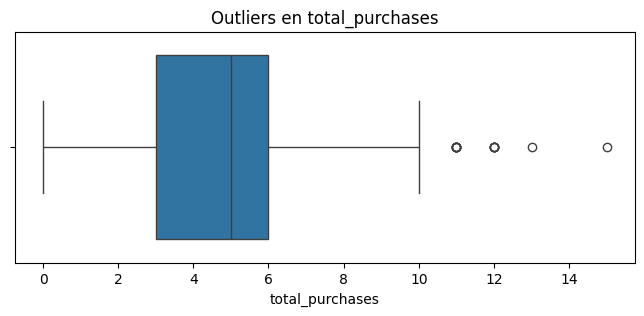

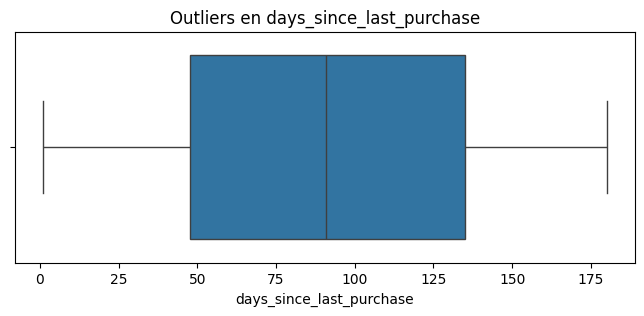

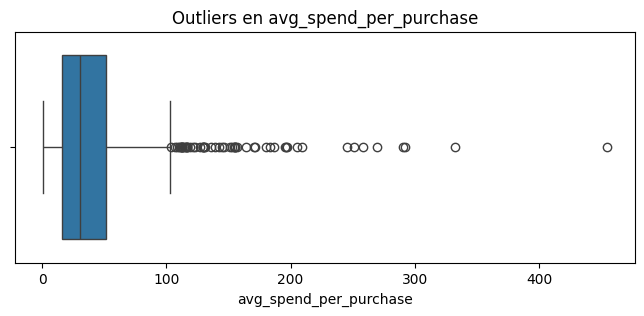

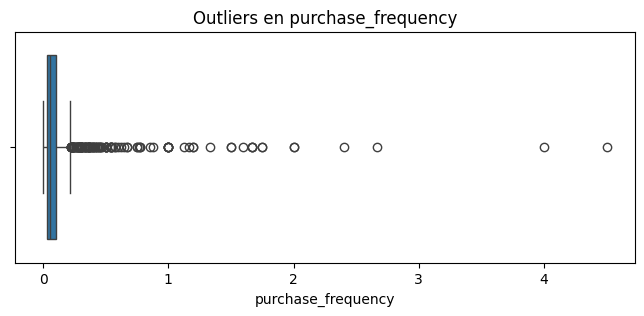

In [13]:
# Boxplots para detectar outliers

for column in numeric_columns:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=X,
        x=column
    )

    plt.title(f'Outliers en {column}')
    plt.show()

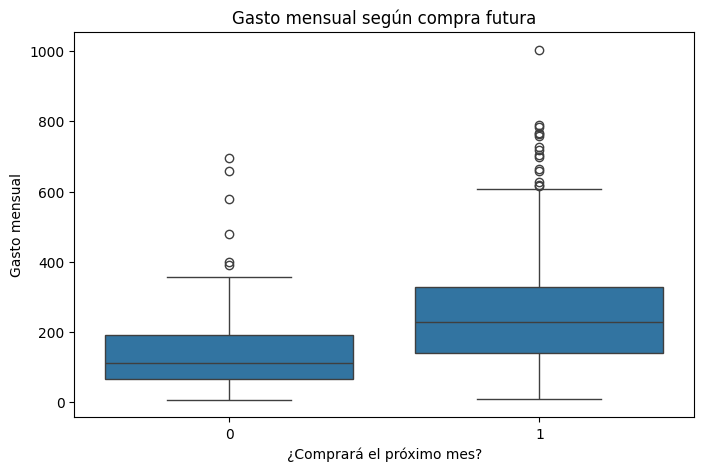

In [14]:
# Relación entre gasto mensual y compra futura

if 'monthly_spend' in X.columns:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=y,
        y=X['monthly_spend']
    )

    plt.title('Gasto mensual según compra futura')
    plt.xlabel('¿Comprará el próximo mes?')
    plt.ylabel('Gasto mensual')
    plt.show()

Variables numéricas y categóricas

In [15]:
# ================================
# 5. DEFINIR COLUMNAS
# ================================

num_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

cat_features = X.select_dtypes(
    include=['object', 'category']
).columns

print("Variables numéricas:", list(num_features))
print("Variables categóricas:", list(cat_features))

Variables numéricas: ['customer_id', 'age', 'monthly_spend', 'total_purchases', 'days_since_last_purchase', 'avg_spend_per_purchase', 'purchase_frequency']
Variables categóricas: ['membership_type', 'gender', 'city']


Pipeline y variables dummy

In [16]:
# ================================
# 6. PREPROCESAMIENTO
# ================================

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, num_features),
        ('cat', categorical_pipeline, cat_features)
    ]
)

División Train, Validation y Test

In [17]:
# ================================
# 7. SPLIT DE DATOS
# ================================

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Shapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Shapes:
Train: (600, 10)
Validation: (200, 10)
Test: (200, 10)


Prevención de Data Leakage

In [18]:
# ================================
# 8. PREPROCESAMIENTO
# ================================

# FIT SOLO EN TRAIN
X_train_prep = preprocessor.fit_transform(X_train)

# TRANSFORM EN VALIDACIÓN
X_val_prep = preprocessor.transform(X_val)

# TRANSFORM EN TEST
X_test_prep = preprocessor.transform(X_test)

print("Datos preprocesados correctamente.")

print("\nDimensiones:")
print("Train:", X_train_prep.shape)
print("Validation:", X_val_prep.shape)
print("Test:", X_test_prep.shape)

Datos preprocesados correctamente.

Dimensiones:
Train: (600, 17)
Validation: (200, 17)
Test: (200, 17)


###Preguntas de reflexión


1. ¿Qué impacto tiene la imputación incorrecta en el rendimiento del modelo?

La imputación incorrecta de valores faltantes puede afectar negativamente el rendimiento del modelo. Si se reemplazan los valores faltantes con valores poco representativos, se puede introducir sesgo en los datos y modificar la distribución original de las variables. Esto puede provocar que el modelo aprenda patrones incorrectos y genere predicciones menos precisas. En esta práctica se utilizó la mediana para las variables numéricas y el valor más frecuente para las variables categóricas, aplicando estas transformaciones dentro del pipeline.

2. ¿Cómo detectaste posibles fuentes de data leakage en tu pipeline?

Para detectar posibles fuentes de Data Leakage se verificó que las transformaciones de los datos, como la imputación y la estandarización, se ajustaran únicamente utilizando el conjunto de entrenamiento. Para ello, se utilizó fit_transform() solamente sobre X_train, mientras que para los conjuntos de validación y prueba se utilizó únicamente transform(). Además, la división de los datos se realizó antes de ajustar el preprocesador. De esta manera, la información de los conjuntos de validación y prueba no influye en el aprendizaje de las transformaciones.

3. ¿Por qué es importante usar una semilla fija en la división de datos?

Utilizar una semilla fija, mediante random_state=42, permite que la división de los datos sea reproducible. Esto significa que cada vez que se ejecuta el código se obtienen los mismos conjuntos de entrenamiento, validación y prueba. Esto facilita la comparación de resultados entre diferentes modelos y experimentos, ya que los cambios observados se deben a las modificaciones realizadas en el modelo o en el procesamiento y no a una división diferente de los datos.